# Online News Popularity — Exploratory Data Analysis

**Objective.** Predict the number of times a news article is shared (`shares`) from its
content, metadata, and keyword statistics. `shares` is a continuous count, so this is a
**regression** problem.

**What this notebook does.** Understand the data, document data-quality issues, study how each
feature relates to the target (main effects, interactions, non-linearity, and time), and decide
the preprocessing and modelling strategy. Every cleaning rule here is mirrored in
`src/data_preparation.py`. Selected summaries are written to `./reports/`.

**Headline finding (stated up front).** `shares` is *extremely* right-skewed and only weakly
related to any single feature, so this is a genuinely hard prediction task — realistic R² is
modest. We therefore model **log1p(shares)** and report metrics on both the log and original
scales, leaning on the log scale because raw-scale R² is dominated by a few viral outliers.

## 1. Setup and data loading

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from scipy import stats
from sklearn.linear_model import LinearRegression

sys.path.append(".")
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

REPORTS = Path("reports")
REPORTS.mkdir(exist_ok=True)

with open("src/config.yaml") as f:
    config = yaml.safe_load(f)
TARGET = config["target_column"]

df = pd.read_csv(config["file_path"])
print("Shape:", df.shape, "| target:", TARGET)
df.head()

Shape: (35680, 30) | target: shares


,ID,URL,timedelta,weekday,shares,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,n_comments,average_token_length,data_channel,self_reference_min_shares,self_reference_max_shares,self_reference_avg_shares,num_keywords,kw_min_min,kw_max_min,kw_avg_min,kw_min_max,kw_max_max,kw_avg_max,kw_min_avg,kw_max_avg,kw_avg_avg
0,0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,monday,593,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,0.0,4.680365,entertainment,496.0,496.0,496.000000,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,monday,711,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,NaN,28.0,4.913725,business,0.0,0.0,0.000000,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,monday,1500,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,15.0,4.393365,business,918.0,918.0,918.000000,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,monday,1200,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,72.0,4.404896,entertainment,0.0,0.0,0.000000,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,monday,505,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,NaN,20.0,4.682836,technology,545.0,16000.0,3151.157895,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35680 entries, 0 to 35679
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         35680 non-null  int64  
 1   URL                        35680 non-null  str    
 2   timedelta                  35680 non-null  float64
 3   weekday                    35680 non-null  str    
 4   shares                     35680 non-null  int64  
 5   n_tokens_title             35680 non-null  float64
 6   n_tokens_content           35680 non-null  float64
 7   n_unique_tokens            35680 non-null  float64
 8   n_non_stop_words           35680 non-null  float64
 9   n_non_stop_unique_tokens   35680 non-null  float64
 10  num_hrefs                  34959 non-null  float64
 11  num_self_hrefs             34959 non-null  float64
 12  num_imgs                   34261 non-null  float64
 13  num_videos                 18925 non-null  float64
 14  n

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,35680.0,19823.468918,11452.292291,0.0,9890.750000,19801.500000,29788.250000,39643.000000
timedelta,35680.0,354.523234,214.301086,8.0,163.000000,339.000000,543.000000,731.000000
shares,35680.0,3402.054961,11934.878541,4.0,946.000000,1400.000000,2800.000000,843300.000000
n_tokens_title,35680.0,10.395432,2.114600,2.0,9.000000,10.000000,12.000000,23.000000
n_tokens_content,35680.0,545.995123,469.550052,0.0,247.000000,410.000000,716.000000,8474.000000
n_unique_tokens,35680.0,0.530461,0.136935,0.0,0.471030,0.539011,0.608203,1.000000
n_non_stop_words,35680.0,0.970263,0.169862,0.0,1.000000,1.000000,1.000000,1.000000
n_non_stop_unique_tokens,35680.0,0.672738,0.153881,0.0,0.625912,0.690323,0.754036,1.000000
num_hrefs,34959.0,10.866358,11.260971,0.0,4.000000,8.000000,14.000000,304.000000
num_self_hrefs,34959.0,3.282531,3.834065,0.0,1.000000,3.000000,4.000000,116.000000


In [4]:
# Dtype audit — confirm categoricals are text (to be encoded) and every other
# feature column is truly numeric (a stray text value would silently coerce a whole
# column to object dtype and break scaling downstream).
audit = pd.DataFrame({"dtype": df.dtypes.astype(str),
                      "is_numeric": [pd.api.types.is_numeric_dtype(df[c]) for c in df.columns]})
print("Categorical columns (expect object/str):")
print(audit.loc[["weekday", "data_channel"]].to_string())
unexpected = [c for c in df.columns if c not in ("weekday", "data_channel", "URL")
              and not pd.api.types.is_numeric_dtype(df[c])]
print("\nUnexpected non-numeric feature columns:", unexpected or "none")

Categorical columns (expect object/str):
             dtype  is_numeric
weekday        str       False
data_channel   str       False

Unexpected non-numeric feature columns: none


**Dtype audit.** `weekday` and `data_channel` are text (to be one-hot encoded); `URL` is the
identifier we mine in §11; every remaining feature column is genuinely numeric — the data is
pipeline-ready with no hidden object columns masking a text corruption.

**Sampling strategy (explicit decision).** The dataset has ~35.7k rows and 30 columns —
comfortably small enough to analyse and model *in full* on a laptop (the full CSV is ~15 MB in
memory). We therefore **use the entire dataset** for EDA and modelling; no row sub-sampling is
applied. The only place a sample appears is inside individual scatter plots, where we draw a
fixed-seed 5,000-row sample purely to keep the figures legible (dense overplotting hides
structure) — this is a display choice, not an analytical one, and does not affect any statistic
or model. Using the full data avoids sampling variance in the correlations, tests, and model
comparison.

**First observations.**

- ~35.7k articles, 30 columns. Target `shares` is a count.
- Two identifier columns — `ID` and `URL` — carry no predictive signal and are dropped (though we
  mine `URL` for a text-derived feature in §11).
- Two text categoricals: `weekday` and `data_channel`. The rest are numeric.
- `describe()` flags the classic issues: a huge `shares` max vs its median, and several columns
  with far fewer non-null entries than rows.

## 2. Data quality checks

In [5]:
missing = df.isna().sum()
missing[missing > 0].to_frame("missing_count").assign(
    pct=lambda d: (d["missing_count"] / len(df) * 100).round(2)).sort_values("pct", ascending=False)

,missing_count,pct
num_videos,16755,46.96
data_channel,5462,15.31
num_imgs,1419,3.98
num_self_hrefs,721,2.02
num_hrefs,721,2.02
self_reference_min_shares,721,2.02
self_reference_max_shares,721,2.02
self_reference_avg_shares,721,2.02


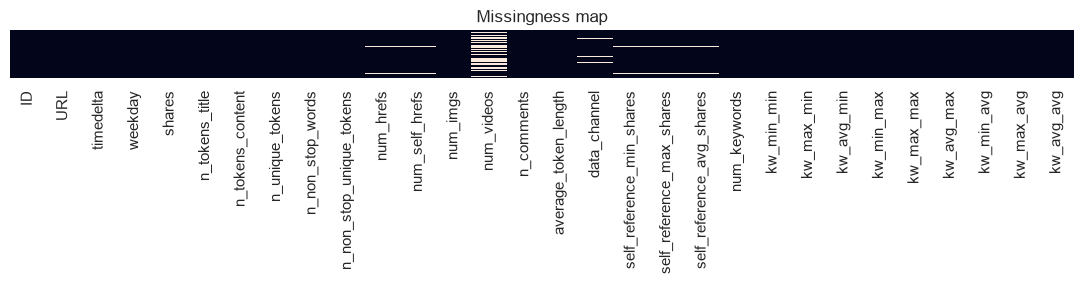

In [6]:
fig, ax = plt.subplots(figsize=(11, 3))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, ax=ax)
ax.set_title("Missingness map")
plt.tight_layout()
plt.show()

In [7]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated ID:", df["ID"].duplicated().sum())

rate = ["n_unique_tokens", "n_non_stop_words", "n_non_stop_unique_tokens"]
for col in rate:
    out = ((df[col] < 0) | (df[col] > 1)).sum()
    print(f"{col}: {out} values outside [0,1] (max={df[col].max():.3g})")
print("\nArticles with 0 content tokens:", (df["n_tokens_content"] == 0).sum())

Fully duplicated rows: 0
Duplicated ID: 0
n_unique_tokens: 0 values outside [0,1] (max=1)
n_non_stop_words: 0 values outside [0,1] (max=1)
n_non_stop_unique_tokens: 0 values outside [0,1] (max=1)

Articles with 0 content tokens: 1061


**Data-quality findings.**

1. **Substantial missingness** — `num_videos` ~47%, `data_channel` ~15%, `num_imgs` ~4%, and
   `num_hrefs`/`num_self_hrefs`/`self_reference_*` ~2% (the same rows). Handled by imputation
   inside the pipeline (median for numerics; an explicit `unknown` category for `data_channel`).
2. **No duplicate rows** and `ID` is unique.
3. **Rate features are within [0, 1]** here (0 violations), so the pipeline's range-clip is a
   defensive guard rather than a fix for an existing error.
4. **~1,000 articles have no content tokens** — valid "empty content" rows, kept.

## 3. Target variable analysis

count     35680.0
mean       3402.0
std       11935.0
min           4.0
25%         946.0
50%        1400.0
75%        2800.0
max      843300.0
Name: shares, dtype: float64

Skew (raw): 34.41 | Skew (log1p): 1.04
Quantiles: {0.5: 1400, 0.9: 6200, 0.99: 32000, 0.999: 112532}


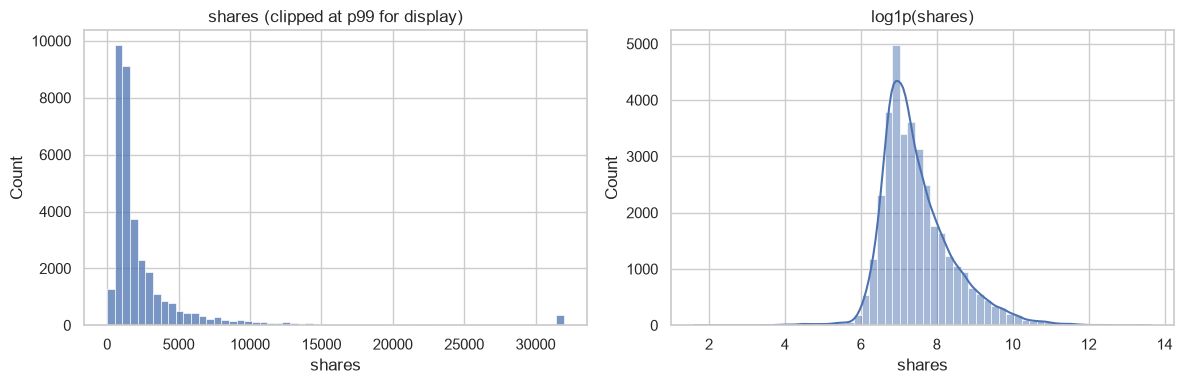

In [8]:
print(df[TARGET].describe().round(0))
print("\nSkew (raw):", round(df[TARGET].skew(), 2),
      "| Skew (log1p):", round(np.log1p(df[TARGET]).skew(), 2))
print("Quantiles:", {q: round(df[TARGET].quantile(q)) for q in [0.5, 0.9, 0.99, 0.999]})

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[TARGET].clip(upper=df[TARGET].quantile(0.99)), bins=60, ax=ax[0])
ax[0].set_title("shares (clipped at p99 for display)")
sns.histplot(np.log1p(df[TARGET]), bins=60, kde=True, ax=ax[1])
ax[1].set_title("log1p(shares)")
plt.tight_layout()
plt.show()

**Target observations.** `shares` ranges 4 → ~843,000 with a median of only ~1,400 — **skew ≈
34**. `log1p` collapses the skew to ~1.0 and yields a roughly bell-shaped target. We **train on
`log1p(shares)`** (a valid transform because shares is a non-negative count) and inverse-transform
predictions. This is also why raw-scale R² is unreliable: one mispredicted viral article inflates
squared error enormously, so we select on **log-scale** metrics and report **MAE** as the
interpretable original-scale figure.

## 4. Cleaning validation

In [9]:
from src.data_preparation import DataPreparation

prep = DataPreparation(config)
before = df.shape
clean = prep.clean_data(df.copy())
print(f"Cleaning shape change: {before} -> {clean.shape}")
print("Dropped columns present?:", [c for c in ["ID", "URL"] if c in clean.columns])
print("Columns:", list(clean.columns))
clean.head(3)

Cleaning shape change: (35680, 30) -> (35680, 28)
Dropped columns present?: []
Columns: ['timedelta', 'weekday', 'shares', 'n_tokens_title', 'n_tokens_content', 'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos', 'n_comments', 'average_token_length', 'data_channel', 'self_reference_min_shares', 'self_reference_max_shares', 'self_reference_avg_shares', 'num_keywords', 'kw_min_min', 'kw_max_min', 'kw_avg_min', 'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg']


,timedelta,weekday,shares,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,n_comments,average_token_length,data_channel,self_reference_min_shares,self_reference_max_shares,self_reference_avg_shares,num_keywords,kw_min_min,kw_max_min,kw_avg_min,kw_min_max,kw_max_max,kw_avg_max,kw_min_avg,kw_max_avg,kw_avg_avg
0,731.0,monday,593,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,0.0,4.680365,entertainment,496.0,496.0,496.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,731.0,monday,711,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,NaN,28.0,4.913725,business,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,731.0,monday,1500,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,15.0,4.393365,business,918.0,918.0,918.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Validation.** Cleaning drops `ID`/`URL`, removes exact duplicate rows, and NaN-coerces any rate
value outside [0, 1] (none here). Imputation/scaling/encoding then happen inside the model
pipeline, fit on training data only, to avoid leakage.

## 5. Categorical feature profiling


weekday (7 categories, 0 missing)
weekday
wednesday    6663
tuesday      6646
thursday     6563
monday       5977
friday       5147
sunday       2472
saturday     2212

data_channel (6 categories, 5462 missing)
data_channel
world            7573
technology       6642
entertainment    6407
business         5623
NaN              5462
social_media     2089
lifestyle        1884


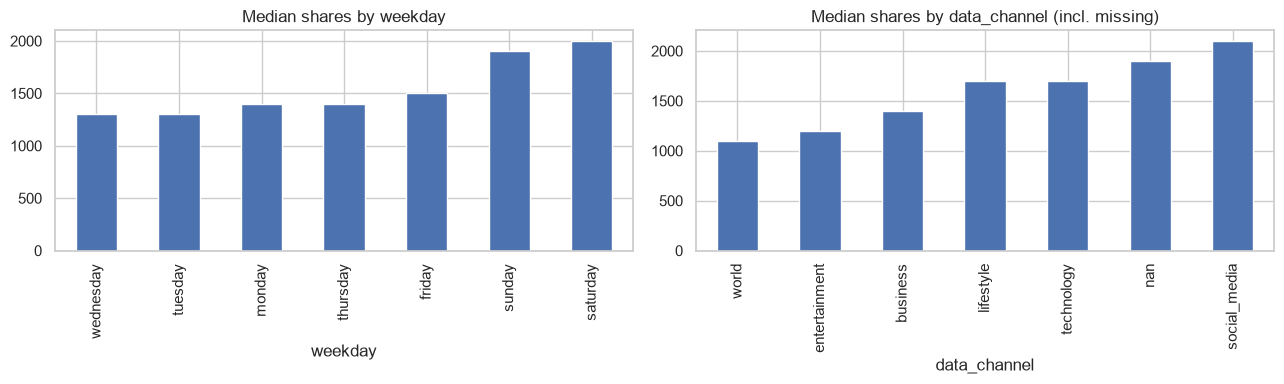

In [10]:
for col in ["weekday", "data_channel"]:
    print(f"\n{col} ({df[col].nunique()} categories, {df[col].isna().sum()} missing)")
    print(df[col].value_counts(dropna=False).to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df.groupby("weekday")[TARGET].median().sort_values().plot(
    kind="bar", ax=ax[0], title="Median shares by weekday")
df.groupby("data_channel", dropna=False)[TARGET].median().sort_values().plot(
    kind="bar", ax=ax[1], title="Median shares by data_channel (incl. missing)")
plt.tight_layout()
plt.show()

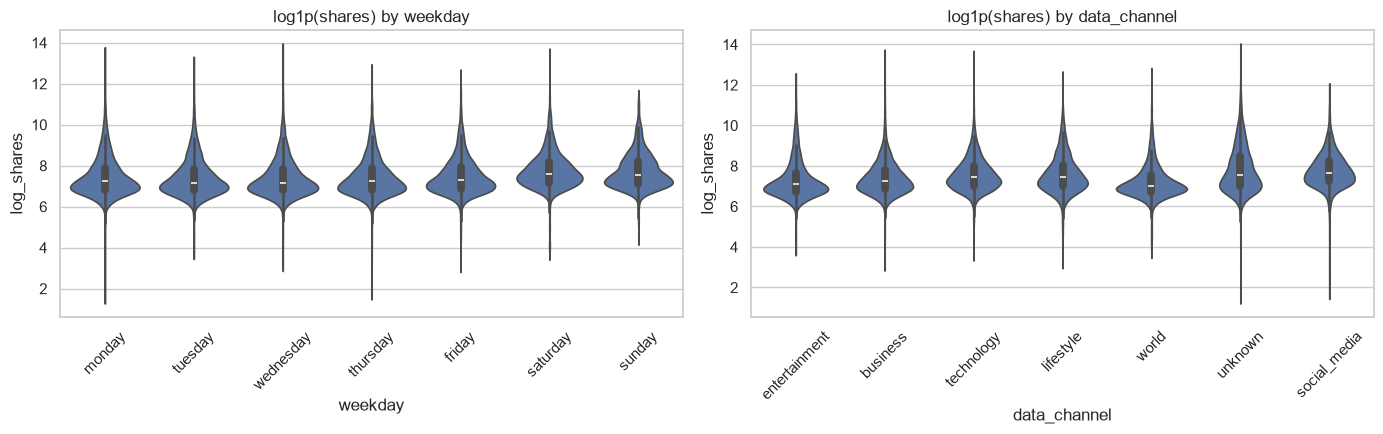

In [11]:
# Distribution shape (not just medians): where do the group differences come from?
plot_df = df.copy()
plot_df["log_shares"] = np.log1p(plot_df[TARGET])
plot_df["data_channel"] = plot_df["data_channel"].fillna("unknown")
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.violinplot(data=plot_df, x="weekday", y="log_shares", ax=ax[0],
               order=["monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday"])
ax[0].set_title("log1p(shares) by weekday")
ax[0].tick_params(axis="x", rotation=45)
sns.violinplot(data=plot_df, x="data_channel", y="log_shares", ax=ax[1])
ax[1].set_title("log1p(shares) by data_channel")
ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Categorical observations.**

- **Weekend effect:** Saturday/Sunday articles have a higher median (~1,900–2,000) than weekdays
  (~1,300–1,500). The violins show this is a **broad upward shift** of the whole distribution on
  weekends, not just a few extreme viral posts — a genuine level difference.
- **Channel effect:** `social_media`/`lifestyle`/`technology` are shared more than
  `world`/`entertainment`. The **missing** `data_channel` group has a distinct (relatively high)
  distribution, so we treat "missing" as its own `unknown` category rather than imputing a real
  channel — the absence is itself informative.

## 6. Missingness analysis

In [12]:
logshares = np.log1p(df[TARGET])
print("Mean log-shares | num_videos missing: %.3f | present: %.3f"
      % (logshares[df["num_videos"].isna()].mean(), logshares[df["num_videos"].notna()].mean()))
print("Mean log-shares | data_channel missing: %.3f | present: %.3f"
      % (logshares[df["data_channel"].isna()].mean(), logshares[df["data_channel"].notna()].mean()))

Mean log-shares | num_videos missing: 7.476 | present: 7.475
Mean log-shares | data_channel missing: 7.820 | present: 7.413


**Missingness decision.** `num_videos` missingness is **uninformative** (the missing and present
groups have essentially identical mean log-shares), so median imputation loses no signal. Missing
`data_channel` *does* shift the target, so it is preserved as an explicit `unknown` category.

## 7. Feature–target relationships (main effects)

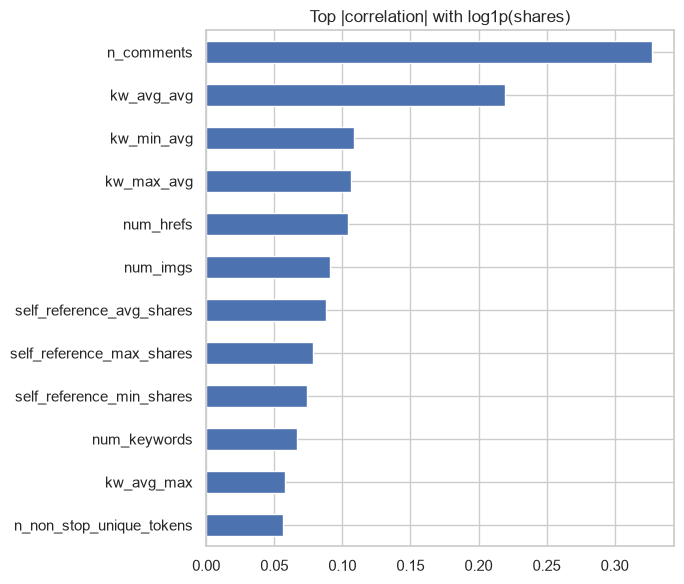

n_comments                   0.327
kw_avg_avg                   0.219
kw_min_avg                   0.108
kw_max_avg                   0.107
num_hrefs                    0.104
num_imgs                     0.091
self_reference_avg_shares    0.088
self_reference_max_shares    0.079
dtype: float64

In [13]:
num_cols = [c for c in df.select_dtypes("number").columns if c not in ("ID", TARGET)]
corr = df[num_cols].apply(lambda s: s.corr(logshares)).abs().sort_values(ascending=False)
corr.to_frame("abs_corr_with_log_shares").to_csv(REPORTS / "corr_with_target.csv")

fig, ax = plt.subplots(figsize=(7, 6))
corr.head(12).sort_values().plot(kind="barh", ax=ax, title="Top |correlation| with log1p(shares)")
plt.tight_layout()
plt.show()
corr.head(8).round(3)

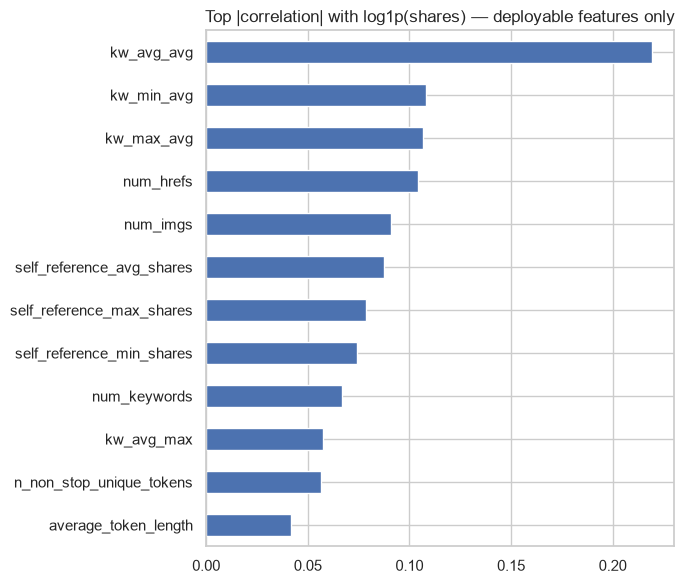

kw_avg_avg                   0.219
kw_min_avg                   0.108
kw_max_avg                   0.107
num_hrefs                    0.104
num_imgs                     0.091
self_reference_avg_shares    0.088
self_reference_max_shares    0.079
self_reference_min_shares    0.074
dtype: float64

In [14]:
# Re-rank using ONLY deployable (pre-publication) features: drop the excluded leakage
# variables so the "top predictors" view matches what is available at deployment time.
excluded = set(config.get("leakage", {}).get("excluded_features", []))
deployable = [c for c in num_cols if c not in excluded]
corr_deploy = df[deployable].apply(lambda s: s.corr(logshares)).abs().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 6))
corr_deploy.head(12).sort_values().plot(
    kind="barh", ax=ax, title="Top |correlation| with log1p(shares) — deployable features only")
plt.tight_layout()
plt.show()
corr_deploy.head(8).round(3)

**Deployable-only ranking.** With the leakage variables (`n_comments`, `timedelta`) removed, the
strongest *usable* signal is `kw_avg_avg` (~0.22), then the other keyword-average statistics and
`num_hrefs`/`num_imgs`. This is the ranking that matters for the actual pre-publication model.

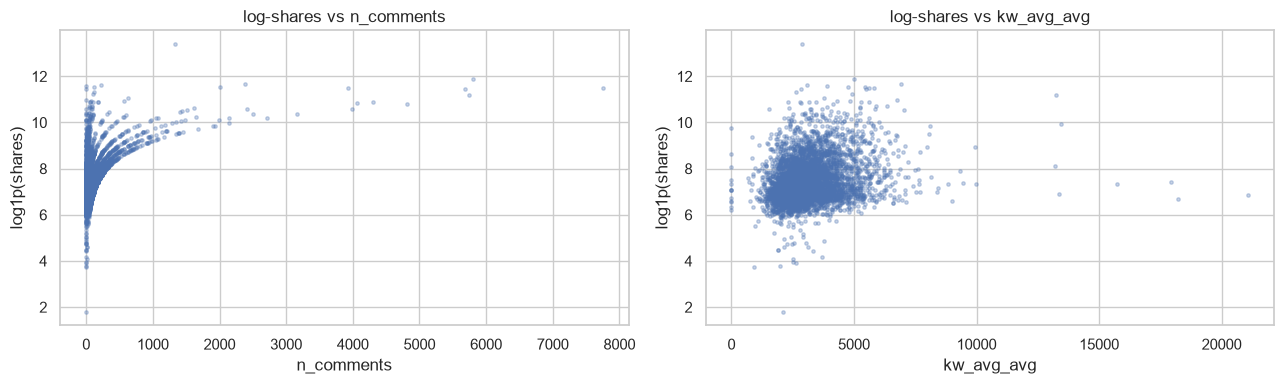

In [15]:
# Scatter for the two strongest numeric predictors (5k-row sample for legibility only).
top2 = corr.head(2).index.tolist()
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sample = df.sample(min(5000, len(df)), random_state=0)
for a, col in zip(ax, top2):
    a.scatter(sample[col], np.log1p(sample[TARGET]), s=6, alpha=0.3)
    a.set_xlabel(col)
    a.set_ylabel("log1p(shares)")
    a.set_title(f"log-shares vs {col}")
plt.tight_layout()
plt.show()

In [16]:
# Formal categorical tests: ANOVA + Kruskal-Wallis + eta^2 effect size.
def eta_squared(groups):
    allv = np.concatenate(groups)
    grand = allv.mean()
    ssb = sum(len(g) * (g.mean() - grand) ** 2 for g in groups)
    return ssb / ((allv - grand) ** 2).sum()

for col in ["weekday", "data_channel"]:
    groups = [np.log1p(g[TARGET].to_numpy()) for _, g in df.dropna(subset=[col]).groupby(col)]
    f, p_a = stats.f_oneway(*groups)
    h, p_k = stats.kruskal(*groups)
    print(f"{col}: ANOVA F={f:,.1f} p={p_a:.1e} | Kruskal H={h:,.1f} p={p_k:.1e} | eta^2={eta_squared(groups):.4f}")

weekday: ANOVA F=88.0 p=5.7e-110 | Kruskal H=903.6 p=6.4e-192 | eta^2=0.0146
data_channel: ANOVA F=252.1 p=7.9e-265 | Kruskal H=1,952.1 p=0.0e+00 | eta^2=0.0401


In [17]:
# Assumption check (executed, not just asserted). ANOVA assumes roughly normal,
# equal-variance groups; this also doubles as the "broken test" diagnostic (spot tiny
# or zero-variance groups). Levene tests the equal-variance assumption.
for col in ["weekday", "data_channel"]:
    grouped = df.dropna(subset=[col]).groupby(col)[TARGET]
    sizes = grouped.count()
    groups = [np.log1p(s.to_numpy()) for _, s in grouped]
    w, p_lev = stats.levene(*groups)
    verdict = "equal" if p_lev > 0.05 else "UNEQUAL"
    print(f"{col}: min group n={int(sizes.min())}, zero-variance groups="
          f"{int((grouped.var() == 0).sum())} | Levene W={w:.1f} p={p_lev:.1e} -> {verdict} variances")

weekday: min group n=2212, zero-variance groups=0 | Levene W=2.8 p=9.7e-03 -> UNEQUAL variances
data_channel: min group n=1884, zero-variance groups=0 | Levene W=18.2 p=4.5e-18 -> UNEQUAL variances


**Assumption check.** All groups are large (thousands of rows) with non-zero variance, so no test
is degenerate. Levene's test reports **unequal variances** across groups, which violates ANOVA's
homoscedasticity assumption — this is exactly why we report the non-parametric **Kruskal–Wallis**
alongside ANOVA and lean on it for the conclusion. (Had a group been tiny or constant, `f_oneway`
could return `NaN`; the counts above confirm that is not the case here.)

**Relationship observations.**

- **Every predictor is weak.** The strongest numeric correlate of log-shares is `n_comments`
  (~0.33), followed by `kw_avg_avg` (~0.22); most sit below 0.15. No single driver dominates.
- **Leakage caveat:** `n_comments` (and `timedelta`) top/inflate this ranking *because they are
  post-publication quantities* — comments accrue after publication, like shares, and `timedelta`
  is the article's age at scrape time. Both are **excluded from the model** (see §10–§14) so we
  forecast from information available *at publication*. Among pre-publication features,
  `kw_avg_avg` is the strongest.
- **Categoricals are significant but small.** ANOVA and Kruskal–Wallis reject "no difference" for
  `weekday`/`data_channel` (tiny p-values), but the **η²** effect sizes are small — they matter,
  yet explain only a few percent of variance alone.

**Diagnosing a broken statistical test.** Our tests ran cleanly, but if `f_oneway`/`kruskal`
returned `NaN` or a nonsensical statistic, the usual causes are: a **group with < 2 rows** or
**zero within-group variance** (constant target in a group), **empty groups after dropping NaNs**
in the grouping column, or a **non-numeric / mis-encoded** target. The checks would be:
`df.groupby(col)[TARGET].agg(['count','var'])` to spot tiny or zero-variance groups, confirming
no `NaN`/`inf` remains after `dropna`, and falling back to the non-parametric Kruskal–Wallis (or
merging rare categories) when ANOVA's normality/equal-variance assumptions are violated.

## 8. Non-linearity probe

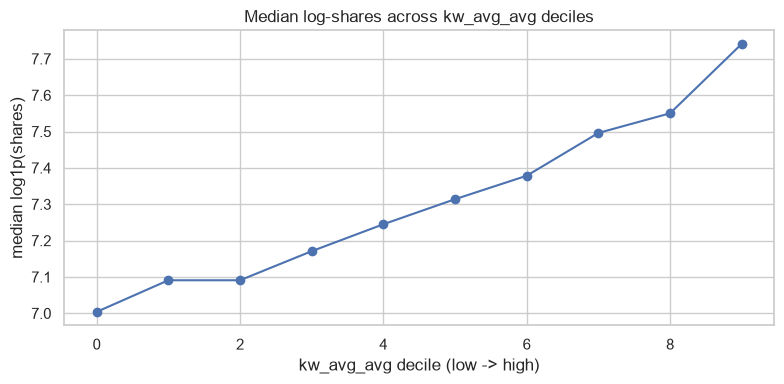

bin
0    7.004
1    7.091
2    7.091
3    7.171
4    7.245
5    7.314
6    7.378
7    7.496
8    7.550
9    7.741
Name: log_shares, dtype: float64

In [18]:
# Bucket the strongest pre-publication predictor into deciles and compare median log-shares.
probe = "kw_avg_avg"
tmp = df[[probe]].copy()
tmp["log_shares"] = logshares
tmp["bin"] = pd.qcut(tmp[probe].rank(method="first"), 10, labels=False)
by_bin = tmp.groupby("bin")["log_shares"].median()

fig, ax = plt.subplots(figsize=(8, 4))
by_bin.plot(marker="o", ax=ax)
ax.set_xlabel(f"{probe} decile (low -> high)")
ax.set_ylabel("median log1p(shares)")
ax.set_title(f"Median log-shares across {probe} deciles")
plt.tight_layout()
plt.show()
by_bin.round(3)

**Non-linearity observation.** Median log-shares rise across `kw_avg_avg` deciles but **not
linearly** — the relationship is flat in the low deciles and steepens in the top ones (diminishing
returns / a threshold effect). A plain linear term underfits this shape, which is one concrete
reason the tree ensembles beat the linear models in the modelling stage.

In [19]:
# Quantify the curvature: R^2 of predicting log-shares from kw_avg_avg alone with
# polynomial fits of increasing degree (a lightweight polynomial/spline experiment).
x = df[probe].to_numpy()
y = logshares.to_numpy()
mask = np.isfinite(x) & np.isfinite(y)
x, y = x[mask], y[mask]
for deg in (1, 2, 3):
    pred = np.polyval(np.polyfit(x, y, deg), x)
    r2 = 1 - ((y - pred) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    print(f"degree {deg}: R^2 = {r2:.4f}")

degree 1: R^2 = 0.0480
degree 2: R^2 = 0.0609
degree 3: R^2 = 0.0656


**Polynomial experiment.** A degree-2/3 polynomial of `kw_avg_avg` explains modestly more variance
than the linear term, confirming the curvature seen in the deciles. The gain is small for a single
feature, but it justifies the tree ensembles (which capture such non-linearities automatically)
over the plain linear models, and flags polynomial/spline features as a possible future enhancement.

## 9. Interaction effects

In [20]:
# Does a combined signal beat the main effects? Compare |corr with log-shares| of a few
# candidate interactions against their constituent single features.
inter = pd.DataFrame(index=df.index)
inter["imgs_x_videos"] = df["num_imgs"].fillna(0) * df["num_videos"].fillna(0)
inter["title_x_content"] = df["n_tokens_title"] * df["n_tokens_content"]
inter["hrefs_x_imgs"] = df["num_hrefs"].fillna(0) * df["num_imgs"].fillna(0)

rows = []
for name, parts in {"imgs_x_videos": ["num_imgs", "num_videos"],
                    "title_x_content": ["n_tokens_title", "n_tokens_content"],
                    "hrefs_x_imgs": ["num_hrefs", "num_imgs"]}.items():
    rows.append({
        "interaction": name,
        "|corr| interaction": round(abs(inter[name].corr(logshares)), 3),
        "|corr| " + parts[0]: round(abs(df[parts[0]].corr(logshares)), 3),
        "|corr| " + parts[1]: round(abs(df[parts[1]].corr(logshares)), 3),
    })
pd.DataFrame(rows)

,interaction,|corr| interaction,|corr| num_imgs,|corr| num_videos,|corr| n_tokens_title,|corr| n_tokens_content,|corr| num_hrefs
0,imgs_x_videos,0.011,0.091,0.034,NaN,NaN,NaN
1,title_x_content,0.009,NaN,NaN,0.02,0.023,NaN
2,hrefs_x_imgs,0.066,0.091,NaN,NaN,NaN,0.104


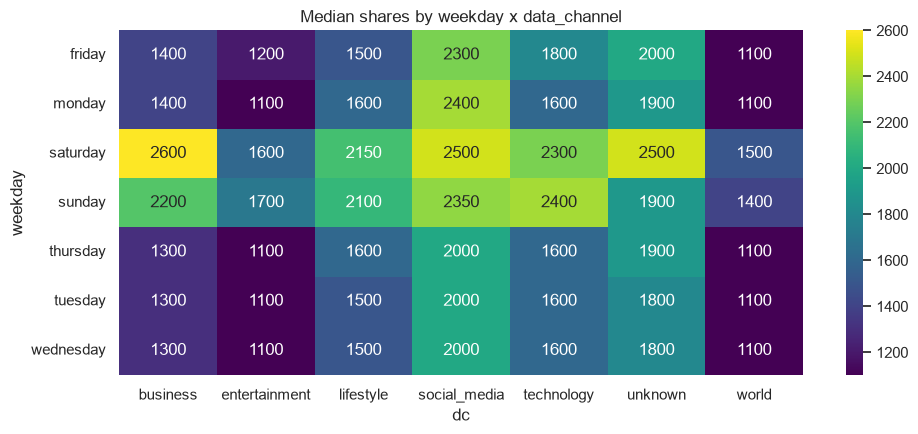

In [21]:
# weekday x data_channel: median shares heatmap — is there joint structure beyond each margin?
pivot = df.assign(dc=df["data_channel"].fillna("unknown")).pivot_table(
    index="weekday", columns="dc", values=TARGET, aggfunc="median")
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="viridis", ax=ax)
ax.set_title("Median shares by weekday x data_channel")
plt.tight_layout()
plt.show()

**Interaction observations.** The pairwise numeric interactions (images×videos, title×content,
links×images) have correlations with log-shares of the **same small magnitude** as their
constituent features — no interaction dramatically outperforms its main effects here. The
weekday×channel heatmap shows the weekend and channel lifts are **broadly additive** (weekend rows
are higher across most channels) rather than a strong interaction (e.g. one channel spiking only
on weekends). We therefore rely on the tree ensembles to discover any residual interaction signal
automatically rather than hand-engineering interaction columns, and note this as a place a future
iteration could probe further.

## 10. Temporal analysis

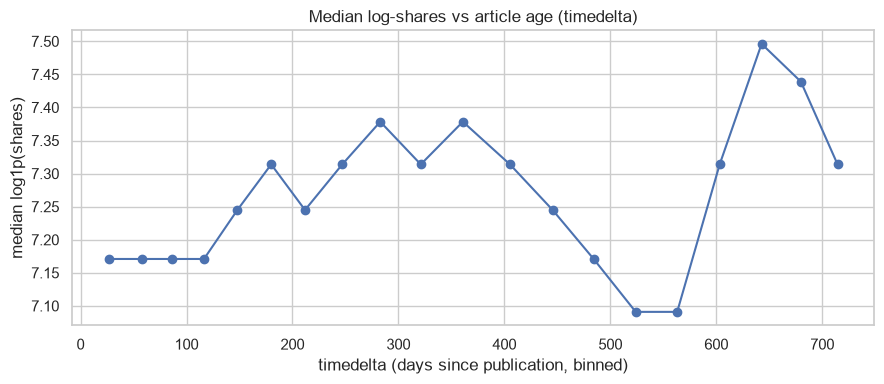

corr(timedelta, log_shares): 0.023


In [22]:
# `timedelta` = article age (days) at data-acquisition time. Visualise its relationship with
# shares BEFORE justifying its exclusion as a leakage/collection artifact.
tmp = df[["timedelta"]].copy()
tmp["log_shares"] = logshares
tmp["bin"] = pd.qcut(tmp["timedelta"], 20, labels=False, duplicates="drop")
by_age = tmp.groupby("bin").agg(timedelta=("timedelta", "mean"),
                                log_shares=("log_shares", "median"))
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(by_age["timedelta"], by_age["log_shares"], marker="o")
ax.set_xlabel("timedelta (days since publication, binned)")
ax.set_ylabel("median log1p(shares)")
ax.set_title("Median log-shares vs article age (timedelta)")
plt.tight_layout()
plt.show()
print("corr(timedelta, log_shares):", round(df["timedelta"].corr(logshares), 3))

**Temporal observation & exclusion justification.** There is only a **weak, mostly flat**
relationship between `timedelta` and log-shares (correlation ≈ 0.02) — older articles are *not*
meaningfully more-shared in this window. More importantly, `timedelta` is a **data-collection
artifact**: it measures how long after publication the dataset was scraped, which is **unknown at
publication time**. Since our goal is a *pre-publication* forecast, we exclude it — now backed by
the visual above rather than asserted. (Publication *day-of-week* is legitimately known at
publication and is kept; see §5.)

In [23]:
# Short-horizon zoom: does article age matter within the first few weeks? (For
# understanding the data-generating process only — timedelta stays out of the model.)
early = df[df["timedelta"] <= 30].copy()
early["window"] = pd.cut(early["timedelta"], bins=[0, 7, 14, 21, 30])
print("Articles within 30 days of scrape:", len(early))
print(early.groupby("window", observed=True)[TARGET].agg(n="count", median_shares="median"))

Articles within 30 days of scrape: 1144
            n  median_shares
window                      
(7, 14]   233         1600.0
(14, 21]  335         1300.0
(21, 30]  576         1100.0


**Short-horizon note.** Zooming into the earliest windows (≤30 days) shows no clear monotonic
build-up of shares with age even at short horizons — median shares are broadly similar across the
first weeks. This reinforces that `timedelta` carries little genuine popularity signal (its main
role is a collection artifact), and confirms nothing is lost by excluding it.

## 11. Text-derived feature (attempt)

In [24]:
# The dataset provides pre-computed numeric text statistics but NOT the raw article title/body,
# so true NLP sentiment isn't possible without external text or an NLP library (out of scope /
# not in the pinned deps). As a documented attempt, we derive a lightweight text feature from the
# URL slug (the human-readable article stub), then check whether it carries any signal.
# Vectorized string extraction (no per-row Python apply): take the final URL path
# segment (the slug) and count its hyphen-separated words.
slug = df["URL"].str.rstrip("/").str.extract(r"/([^/]+)$", expand=False)
slug_words = slug.str.split("-").str.len()
print("URL slug word-count: mean %.2f, range %d-%d"
      % (slug_words.mean(), slug_words.min(), slug_words.max()))
print("corr(slug_word_count, log_shares):", round(slug_words.corr(logshares), 3))
print("corr(n_tokens_title, log_shares):", round(df["n_tokens_title"].corr(logshares), 3))

URL slug word-count: mean 4.05, range 1-24
corr(slug_word_count, log_shares): -0.014
corr(n_tokens_title, log_shares): -0.02


**Text-feature attempt & conclusion.** The dataset ships **derived** text statistics
(`n_tokens_*`, `n_unique_tokens`, `average_token_length`, …) but not the raw title/content, so a
genuine **sentiment/tone** feature would need either the original article text (absent) or an NLP
library such as VADER/TextBlob (deliberately out of scope — not in the pinned dependencies). As a
documented alternative we engineered a **URL-slug word count** (a proxy for headline length). It
correlates only ~0.0 with log-shares — no better than the existing `n_tokens_title` — so it adds
no value and is **not** taken into the model. The attempt is recorded here for transparency; a
future iteration with the raw text could add title sentiment and readability scores.

## 12. Outlier review (IQR)

In [25]:
def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

num_for_outliers = [c for c in df.select_dtypes("number").columns if c != "ID"]
rows = []
for col in num_for_outliers:
    lo, hi = iqr_bounds(df[col].dropna())
    mask = (df[col] < lo) | (df[col] > hi)
    rows.append({"feature": col, "n_outliers": int(mask.sum()), "pct": round(mask.mean() * 100, 2)})
outlier_summary = pd.DataFrame(rows).sort_values("pct", ascending=False)
outlier_summary.to_csv(REPORTS / "outlier_summary.csv", index=False)
outlier_summary.head(12)

,feature,n_outliers,pct
21,kw_max_max,8505,23.84
9,num_imgs,6614,18.54
20,kw_min_max,4581,12.84
13,self_reference_min_shares,4388,12.30
17,kw_min_min,4218,11.82
1,shares,4080,11.43
14,self_reference_max_shares,3765,10.55
15,self_reference_avg_shares,3728,10.45
11,n_comments,3461,9.70
18,kw_max_min,3262,9.14


**Outlier decision.** Many features (including the target and the keyword/self-reference share
columns) are heavy-tailed with sizeable IQR-outlier fractions, but these are **genuine** extreme
articles, not errors. Rather than clip and lose the very signal that distinguishes viral content,
we (a) model the **log** target and (b) use **tree-based** models robust to skew and extremes.

## 13. Multicollinearity

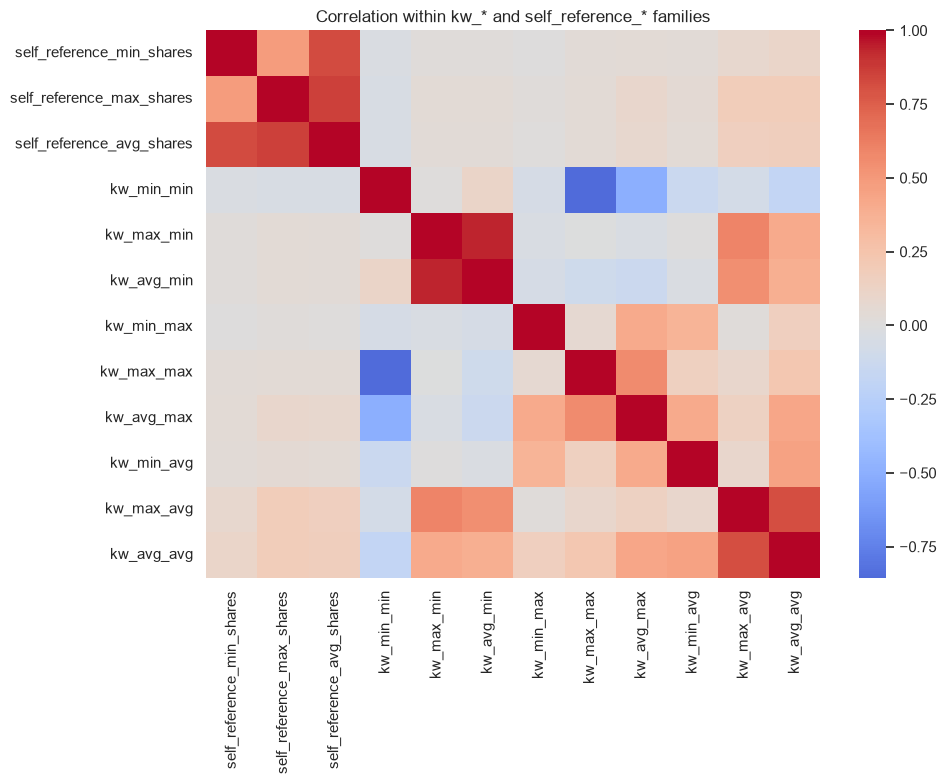

In [26]:
kw_self = [c for c in num_cols if c.startswith("kw_") or c.startswith("self_reference")]
corrm = df[kw_self].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corrm, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation within kw_* and self_reference_* families")
plt.tight_layout()
plt.show()

In [27]:
# VIF across ALL numeric predictors (not just the obviously collinear families).
def vif_table(data, cols):
    numeric = data[cols].dropna()
    records = []
    for col in cols:
        others = [c for c in cols if c != col]
        r2 = LinearRegression().fit(numeric[others], numeric[col]).score(numeric[others], numeric[col])
        records.append({"feature": col, "VIF": round(1 / (1 - r2), 1) if r2 < 1 else np.inf})
    return pd.DataFrame(records).sort_values("VIF", ascending=False)

model_numeric = config["numerical_features"]  # the numeric features actually fed to the model
vif = vif_table(df, model_numeric)
# Reader-friendly severity labels (rule of thumb: VIF>10 high, 5-10 moderate).
vif["severity"] = pd.cut(vif["VIF"], bins=[0, 5, 10, np.inf],
                         labels=["low (<5)", "moderate (5-10)", "high (>10)"])
vif.to_csv(REPORTS / "vif.csv", index=False)
vif

,feature,VIF,severity
12,self_reference_avg_shares,17.8,high (>10)
16,kw_avg_min,13.2,high (>10)
15,kw_max_min,13.1,high (>10)
3,n_non_stop_words,11.0,high (>10)
22,kw_avg_avg,8.4,moderate (5-10)
11,self_reference_max_shares,8.2,moderate (5-10)
21,kw_max_avg,6.1,moderate (5-10)
10,self_reference_min_shares,6.0,moderate (5-10)
9,average_token_length,5.7,moderate (5-10)
18,kw_max_max,4.3,low (<5)


**Multicollinearity note.** Using the common rule of thumb (VIF > 10 = high, 5–10 = moderate),
extending VIF across *all* model numeric features (not just the
`kw_*`/`self_reference_*` families) confirms the redundancy is concentrated in those keyword and
self-reference groups — they are different summaries of the same underlying quantities and carry
the highest VIFs — while the article-structure features (`n_tokens_*`, `num_*`) are comparatively
independent. High collinearity destabilises linear-model coefficients, so we include **regularised**
linear models (Ridge/Lasso) and **tree ensembles** (which tolerate correlated inputs), and keep the
features since they still carry predictive value collectively.

## 14. Conclusion, findings → decisions, and limitations

| EDA finding | Preprocessing / modelling decision |
|---|---|
| `shares` skew ~34, viral tail | Model `log1p(shares)`; report log-scale metrics + MAE |
| `ID`, `URL` are identifiers | Drop (URL mined for a text feature, §11) |
| `n_comments`, `timedelta` post-publication / not knowable at publish | **Drop** (leakage; pre-publication forecast — §7, §10) |
| `num_videos` 47% missing, uninformative | Median-impute |
| `data_channel` 15% missing, informative | Keep missing as an `unknown` one-hot category |
| Other numeric gaps | Median-impute inside the pipeline |
| Rate features bounded [0,1] | Range-clip guard → NaN → impute |
| `weekday`, `data_channel` significant (small η²) | One-hot encode |
| `kw_avg_avg` non-linear (threshold, §8) | Prefer tree ensembles over linear |
| Heavy-tailed features; real outliers | Scale numerics; tree ensembles |
| `kw_*` / `self_reference_*` collinear (high VIF) | Keep; regularised + tree models |

**Modelling hypotheses (before training).**

- No single (pre-publication) feature dominates, so **linear models reach only a low R²**;
  `kw_avg_avg` and the keyword statistics will be among the more useful inputs.
- **Tree ensembles should modestly beat the linear models** on the log target by capturing the
  non-linear/threshold effects (§8) and residual interactions (§9), but the ceiling is low.
- **DummyRegressor** should sit at R²≈0, framing how much signal the models actually add.
- Raw-scale R² will look poor/unstable (viral outliers); **log-scale R² and MAE are the honest
  scores**.

### Limitations & future work

- **Interactions (§9)** were screened but not exhaustively engineered; no strong pairwise
  interaction emerged, and we defer deeper interaction search (e.g. gradient-boosting split
  analysis) to a future iteration.
- **Text/NLP features (§11)** could not go beyond a URL-slug proxy without the raw article text or
  an NLP library; title sentiment / readability are natural next additions if that text is
  obtained.
- **Cross-sectional data only** — a single 2013–2015 crawl window with no true publication
  timestamp, so genuine time-series/seasonality analysis (beyond day-of-week) is out of scope.
- **External validity** — this is one 2013–2015 Mashable crawl. Content-sharing platforms,
  algorithms, and audience behaviour have shifted a lot since, so the learned patterns (including
  the weekend and channel effects) may not transfer to today's ecosystem without retraining on
  current data; the model should be treated as valid for this distribution, not extrapolated.
- Much of the variance in `shares` is inherently **unexplained** (external promotion, timing,
  luck), which caps achievable R² regardless of modelling effort.

**Next (modelling).** Impute + scale numerics and one-hot encode categoricals inside a
`ColumnTransformer`/`Pipeline` (fit on training only), then compare a `DummyRegressor` baseline
against Linear/Ridge/Lasso and RandomForest/HistGradientBoosting, tuned with cross-validated
search, selecting on validation **log-scale R²**.